In [1]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit_ibm_runtime.fake_provider import FakeManilaV2
from qiskit.visualization import plot_histogram, plot_distribution

import qiskit.quantum_info as qi
import numpy as np
import time

In [2]:
def oracle(n, states):
  qc = QuantumCircuit(n)
  for state in states:
    # Inverter onde é 0 para 1: motivo simular a porta CZ
    for i, bit in enumerate(reversed(state)):
      if bit == '0':
        qc.x(i)
    
    # Simular a porta CZ múltipla para inverter a fase (marcar os estados com a fase)
    qc.h(n - 1)
    qc.mcx(list(range(n - 1)), n - 1)
    qc.h(n - 1)

    # Reverte os X para manter o estado original
    for i, bit in enumerate(reversed(state)):
      if bit == '0':
        qc.x(i)
  return qc.to_instruction(label='Oracle')

def diffuser(n):
  qc = QuantumCircuit(n)
  # Colocar todos em H e X
  qc.h(range(n))
  qc.x(range(n))
  # Simular a multi-controlada Z
  qc.h(n-1)
  qc.mcx(list(range(n-1)), n-1)
  qc.h(n-1)
  # Desfazer X e H
  qc.x(range(n))
  qc.h(range(n))
  return qc.to_instruction(label='Diffusion')

def create_grover_circuit(marked):
  n = len(marked[0]) 

  iterations = int(np.floor(np.pi / 4 * np.sqrt(2 ** n / len(marked))))

  qc = QuantumCircuit(n, n)
  qc.h(range(n)) 
  qc.barrier()

  for i in range(iterations):
    qc.append(oracle(n, marked), list(range(n)))
    qc.barrier()
    qc.append(diffuser(n), list(range(n)))
    qc.barrier()

  qc.measure(list(range(n)), list(range(n)))
  return qc, iterations

def execute(qc, shots=1024, fake=False):
  start = time.perf_counter_ns()
  qc_t = transpile(qc)
  backend = AerSimulator() if not fake else FakeManilaV2()

  result = backend.run(qc_t.decompose(), shots=shots, seed_simulator=42).result()
  return result.get_counts(), time.perf_counter_ns() - start

def format(ns):
  horas = ns // (3600 * 10**9)
  minutos = (ns // (60 * 10**9)) % 60
  segundos = (ns // 10**9) % 60
  milissegundos = (ns // 10**6) % 1000
  nanosegundos = ns % 10**6

  return f"{horas}h {minutos}m {segundos}s {milissegundos}ms {nanosegundos}ns"

def linear_search(n):
  count = 0
  start = time.perf_counter_ns()
  for _ in range(2 ** n): # -1 é o limite superior do range
     count += 1
  return count, time.perf_counter_ns() - start 

In [ ]:
# Cenário 3
print('iterations;nanoseconds;nano_format;counts')
for n in range(2, 32):
    print(f'QUBITS {n}')
    qc, iterations = create_grover_circuit(['1' * n])

    counts, duration = execute(qc, shots=1024, fake=False)

    print(f'{iterations};{duration};{format(duration)};{counts}')

    iterations, duration_linear_search = linear_search(n)
    print(f'{iterations};{duration_linear_search};{format(duration_linear_search)};0')


iterations;nanoseconds;nano_format;counts
QUBITS 2
1;15727400;0h 0m 0s 15ms 727400ns;{'11': 1024}
4;2800;0h 0m 0s 0ms 2800ns;0
QUBITS 3
2;20442400;0h 0m 0s 20ms 442400ns;{'111': 982, '101': 7, '110': 11, '001': 4, '010': 6, '000': 3, '100': 5, '011': 6}
8;2900;0h 0m 0s 0ms 2900ns;0
QUBITS 4
3;20305200;0h 0m 0s 20ms 305200ns;{'0110': 2, '1111': 1000, '1110': 2, '0101': 1, '1101': 2, '0100': 3, '0010': 1, '1001': 1, '1000': 2, '1100': 1, '0000': 2, '1011': 3, '0111': 2, '1010': 2}
16;2800;0h 0m 0s 0ms 2800ns;0
QUBITS 5
4;22902600;0h 0m 0s 22ms 902600ns;{'11111': 1022, '11010': 1, '11011': 1}
32;3400;0h 0m 0s 0ms 3400ns;0
QUBITS 6
6;23590600;0h 0m 0s 23ms 590600ns;{'111111': 1022, '001101': 2}
64;3800;0h 0m 0s 0ms 3800ns;0
QUBITS 7
8;26203100;0h 0m 0s 26ms 203100ns;{'0010100': 2, '1111111': 1022}
128;5600;0h 0m 0s 0ms 5600ns;0
QUBITS 8
12;34942500;0h 0m 0s 34ms 942500ns;{'11111111': 1024}
256;9800;0h 0m 0s 0ms 9800ns;0
QUBITS 9
17;50710300;0h 0m 0s 50ms 710300ns;{'111111111': 1024}
512;37

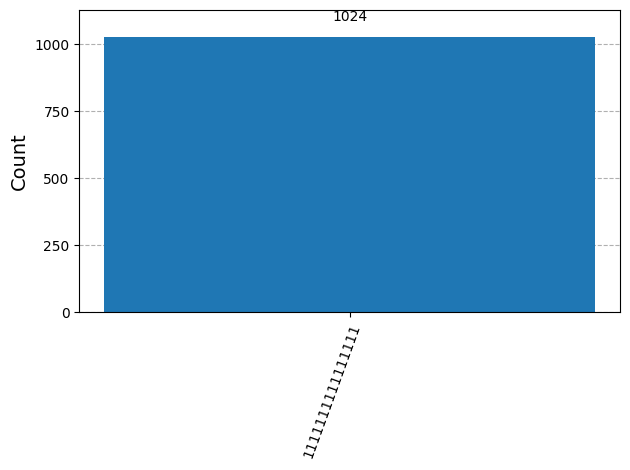

In [ ]:
# Cenário 3 - continuação
print('iterations;nanoseconds;nano_format;counts')
for n in range(26, 32):
    print(f'QUBITS {n}')
    qc, iterations = create_grover_circuit(['1' * n])

    counts, duration = execute(qc, shots=1024, fake=False)

    print(f'{iterations};{duration};{format(duration)};{counts}')

    iterations, duration_linear_search = linear_search(n)
    print(f'{iterations};{duration_linear_search};{format(duration_linear_search)};0')


In [ ]:
qc.decompose().draw('mpl', fold=1)